# Parte 1 — Datos y Tokenización
### Workshop: Clasificación de Emociones en Twitter

Este notebook cubre:
- Exploración del dataset TweetEval Emotion (EDA)
- Análisis comparativo de tokenización: DistilBERT vs BERTweet
- Guarda el dataset crudo para que los siguientes notebooks lo carguen directamente

> **Referencia:** Barbieri et al. (2020). *TweetEval: Unified Benchmark and Comparative Evaluation for Tweet Classification*. EMNLP Findings.

In [15]:
# !pip install 'transformers[torch]' 'accelerate>=1.1.0' datasets evaluate scikit-learn matplotlib seaborn -q

In [16]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
from datasets import load_dataset
from transformers import AutoTokenizer

SEED = 42
MAX_LENGTH = 128
LABEL_NAMES = ["anger", "joy", "optimism", "sadness"]
ID2LABEL = {i: l for i, l in enumerate(LABEL_NAMES)}
LABEL2ID = {l: i for i, l in enumerate(LABEL_NAMES)}
PALETTE = {"anger": "#e74c3c", "joy": "#f1c40f",
           "optimism": "#2ecc71", "sadness": "#3498db"}

np.random.seed(SEED)
torch.manual_seed(SEED)
print("Config OK")

Config OK


## 1. Carga del dataset

In [17]:
raw = load_dataset("tweet_eval", "emotion")
print(raw)
print("\nEjemplos por split:")
for split in raw:
    print(f"  {split}: {len(raw[split])} ejemplos")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})

Ejemplos por split:
  train: 3257 ejemplos
  test: 1421 ejemplos
  validation: 374 ejemplos


In [18]:
print("Primeros 6 ejemplos del split de entrenamiento:\n")
for ex in raw["train"].select(range(6)):
    print(f"  [{ID2LABEL[ex['label']].upper():<10}]  {ex['text']}")

Primeros 6 ejemplos del split de entrenamiento:

  [OPTIMISM  ]  “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry
  [ANGER     ]  My roommate: it's okay that we can't spell because we have autocorrect. #terrible #firstworldprobs
  [JOY       ]  No but that's so cute. Atsu was probably shy about photos before but cherry helped her out uwu
  [ANGER     ]  Rooneys fucking untouchable isn't he? Been fucking dreadful again, depay has looked decent(ish)tonight
  [SADNESS   ]  it's pretty depressing when u hit pan on ur favourite highlighter
  [ANGER     ]  @user but your pussy was weak from what I heard so stfu up to me bitch . You got to threaten him that your pregnant .


## 2. EDA

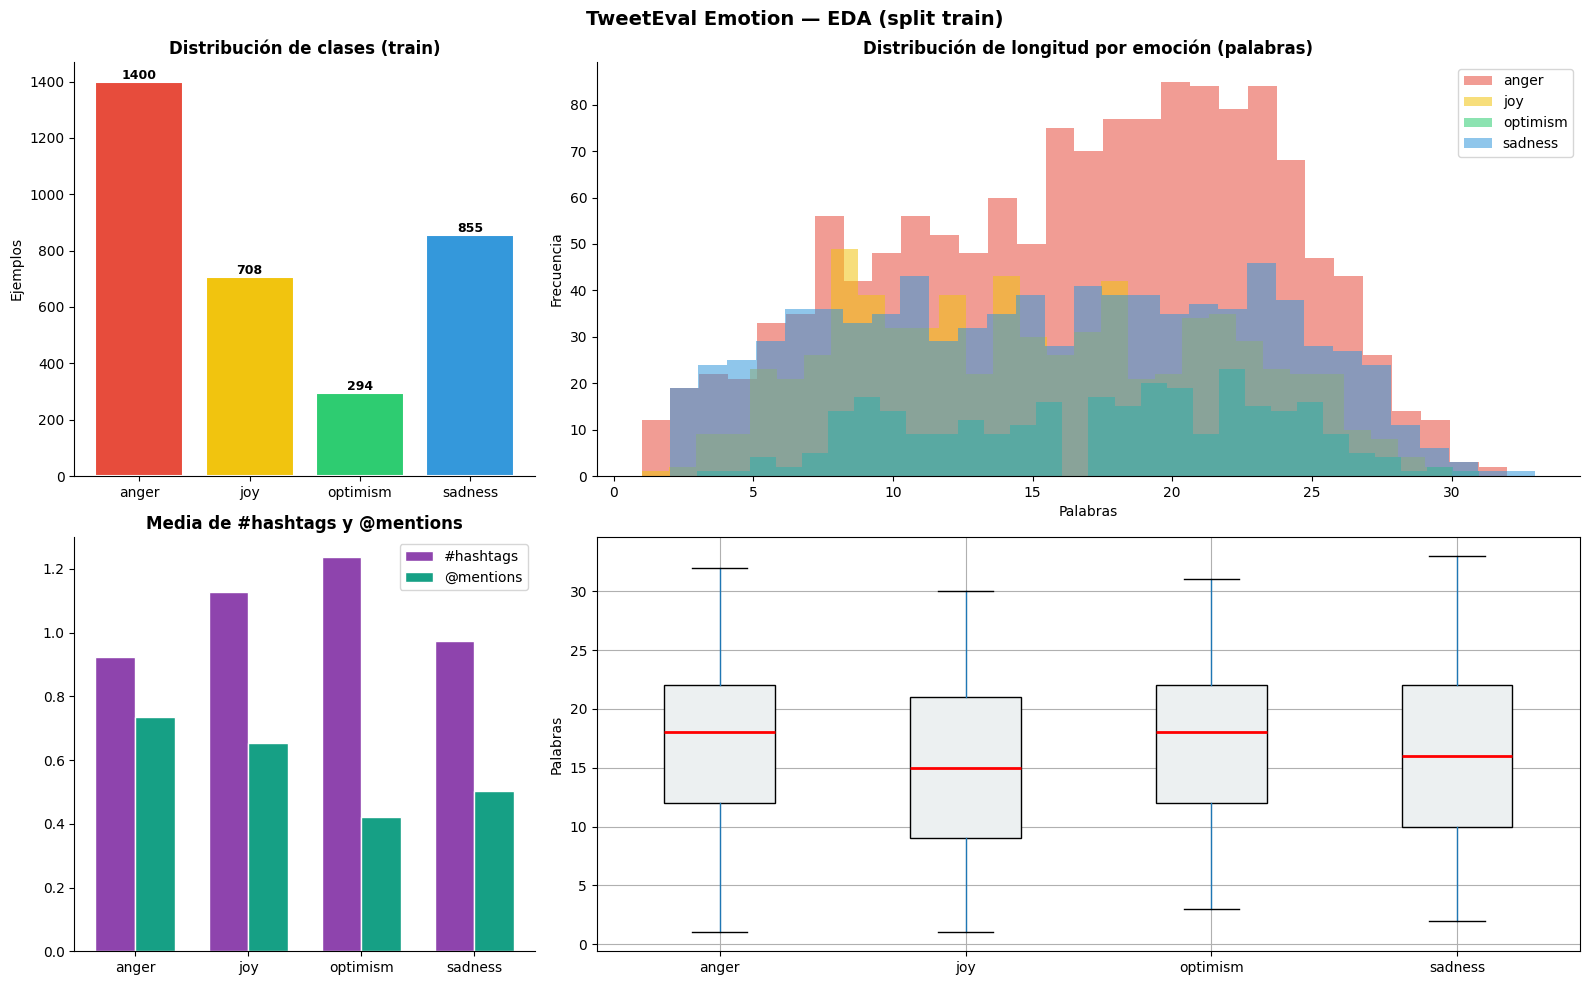


Conteo de clases en cada split:
  train: anger=1400 (43%)  joy=708 (22%)  optimism=294 (9%)  sadness=855 (26%)
  test: anger=558 (39%)  joy=358 (25%)  optimism=123 (9%)  sadness=382 (27%)
  validation: anger=160 (43%)  joy=97 (26%)  optimism=28 (7%)  sadness=89 (24%)


In [19]:
df = raw["train"].to_pandas()
df["emotion"] = df["label"].map(ID2LABEL)
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()
df["n_hashtags"] = df["text"].str.count(r"#\w+")
df["n_mentions"] = df["text"].str.count(r"@\w+")

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
counts = df["emotion"].value_counts().reindex(LABEL_NAMES)
bars = ax1.bar(counts.index, counts.values,
               color=[PALETTE[k] for k in counts.index], edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"{val}", ha="center", fontweight="bold", fontsize=9)
ax1.set_title("Distribución de clases (train)", fontweight="bold")
ax1.set_ylabel("Ejemplos")
ax1.spines[["top", "right"]].set_visible(False)

ax2 = fig.add_subplot(gs[0, 1:3])
for emotion in LABEL_NAMES:
    subset = df[df["emotion"] == emotion]
    ax2.hist(subset["n_words"], bins=30, alpha=0.55,
             label=emotion, color=PALETTE[emotion], edgecolor="none")
ax2.set_title("Distribución de longitud por emoción (palabras)", fontweight="bold")
ax2.set_xlabel("Palabras"); ax2.set_ylabel("Frecuencia")
ax2.legend(); ax2.spines[["top", "right"]].set_visible(False)

ax3 = fig.add_subplot(gs[1, 0])
means = df.groupby("emotion")[["n_hashtags", "n_mentions"]].mean().reindex(LABEL_NAMES)
x = np.arange(len(LABEL_NAMES)); w = 0.35
ax3.bar(x - w/2, means["n_hashtags"], w, label="#hashtags", color="#8e44ad", edgecolor="white")
ax3.bar(x + w/2, means["n_mentions"], w, label="@mentions", color="#16a085", edgecolor="white")
ax3.set_xticks(x); ax3.set_xticklabels(LABEL_NAMES)
ax3.set_title("Media de #hashtags y @mentions", fontweight="bold")
ax3.legend(); ax3.spines[["top", "right"]].set_visible(False)

ax4 = fig.add_subplot(gs[1, 1:3])
df.boxplot(column="n_words", by="emotion",
           positions=range(len(LABEL_NAMES)), ax=ax4,
           patch_artist=True, boxprops=dict(facecolor="#ecf0f1"),
           medianprops=dict(color="red", linewidth=2))
ax4.set_xticklabels(LABEL_NAMES)
ax4.set_title("Longitud por emoción", fontweight="bold")
ax4.set_xlabel(""); ax4.set_ylabel("Palabras")
plt.sca(ax4); plt.title("")

fig.suptitle("TweetEval Emotion — EDA (split train)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nConteo de clases en cada split:")
for split in raw:
    c = Counter(raw[split]["label"])
    total = sum(c.values())
    print(f"  {split}: " + "  ".join(
        f"{ID2LABEL[k]}={v} ({v/total*100:.0f}%)" for k, v in sorted(c.items())))

### Observaciones del EDA

**¿Hay desequilibrio de clases? ¿Cuál es la clase mayoritaria?**

Sí, hay un desequilibrio notable. Específicamente, *Anger* es la clase mayoritaria (43% del train), seguida de *sadness* (26.3%), *joy* (21.7%) y *optimism* (9%) como clase minoritaria. Un clasificador que predijera siempre "anger" alcanzaría aproximadamente un 43% de accuracy sin aprender nada, lo que evidencia que la accuracy sola podría ser una métrica engañosa aquí.

**¿Cuántos tokens tienen aproximadamente los tweets? ¿Justifica `MAX_LENGTH=128`?**

Los tweets del split de train tienen una media de 25.5 tokens con DistilBERT y 22.9 tokens con BERTweet, con valores máximos de 62 y 55 respectivamente. El 0% de los tweets supera los 128 tokens con cualquiera de los dos tokenizadores, por lo que `MAX_LENGTH=128` está justificado y no provoca ningún truncamiento.

**¿Qué características de Twitter (hashtags, mentions) podrían afectar a un tokenizador entrenado en texto formal?**

Las características como hashtags, las menciones y los emojis podrían afectar a un tokenizador entrenado en texto formal. En el caso de DistilBERT, los hashtags (`#wtf`) se fragmentan en `['#', 'w', '##tf']`, Las menciones (`@user`) se dividen en `['@', 'user']`, y los emojis (`😊`, `😢`) producen `[UNK]` porque no existen en el vocabulario WordPiece de texto formal, lo que se hace que se pierda la semántica completa de estos elementos. Por el contrario, BERTweet los trata como unidades nativas: `#wtf → ['#wtf']`, `@user → ['@USER']`, `😊 → [':smiling_face_with_smiling_eyes:']`, produciendo representaciones más ricas y coherentes. 

> ⚠️ Con clases desbalanceadas la *accuracy* puede ser engañosa. Usaremos **F1 macro** como métrica principal.

## 3. Tokenización comparativa

DistilBERT fue pre-entrenado en Wikipedia y BookCorpus — texto formal. Su tokenizador no conoce abreviaciones de Twitter, hashtags ni emojis.

BERTweet fue pre-entrenado en 850M tweets. Su tokenizador fue entrenado sobre texto de Twitter, incluyendo `@mentions`, `#hashtags` y emojis normalizados.

In [20]:
tok_distilbert = AutoTokenizer.from_pretrained("distilbert-base-uncased")
tok_bertweet   = AutoTokenizer.from_pretrained("vinai/bertweet-base", normalization=True)

def compare_tokenization(text, label=""):
    toks_d = tok_distilbert.tokenize(text)
    toks_b = tok_bertweet.tokenize(text)
    print(f"\n{'─'*65}")
    print(f"  [{label}] {text}" if label else f"  {text}")
    print(f"{'─'*65}")
    print(f"  DistilBERT  ({len(toks_d):2d} tokens): {toks_d}")
    print(f"  BERTweet    ({len(toks_b):2d} tokens): {toks_b}")

examples = [
    ("I'm so happy today!!! 😊",                        "joy"),
    ("this is absolutely disgusting #angry #wtf",       "anger"),
    ("@user can't believe what just happened... 😢",    "sadness"),
    ("RT @user: The future looks bright #hope #goals",  "optimism"),
]

for text, label in examples:
    compare_tokenization(text, label)


─────────────────────────────────────────────────────────────────
  [joy] I'm so happy today!!! 😊
─────────────────────────────────────────────────────────────────
  DistilBERT  (10 tokens): ['i', "'", 'm', 'so', 'happy', 'today', '!', '!', '!', '[UNK]']
  BERTweet    ( 9 tokens): ['I', "'m", 'so', 'happy', 'today', '!', '!', '!', ':smiling_face_with_smiling_eyes:']

─────────────────────────────────────────────────────────────────
  [anger] this is absolutely disgusting #angry #wtf
─────────────────────────────────────────────────────────────────
  DistilBERT  ( 9 tokens): ['this', 'is', 'absolutely', 'disgusting', '#', 'angry', '#', 'w', '##tf']
  BERTweet    ( 7 tokens): ['this', 'is', 'absolutely', 'disgusting', '#@@', 'angry', '#wtf']

─────────────────────────────────────────────────────────────────
  [sadness] @user can't believe what just happened... 😢
─────────────────────────────────────────────────────────────────
  DistilBERT  (13 tokens): ['@', 'user', 'can', "'", 't', 'b

### 📝 TODO 2.1 — Análisis de tokenización

1. ¿Cuántos tokens produce en promedio cada tokenizador sobre todos los tweets del split de train?

In [22]:
train_texts = raw["train"]["text"]

lens_d = [len(tok_distilbert(t)["input_ids"]) for t in train_texts]
lens_b = [len(tok_bertweet(t)["input_ids"])   for t in train_texts]

print(f"DistilBERT — media: {np.mean(lens_d):.1f}  mediana: {np.median(lens_d):.0f}  máx: {max(lens_d)}")
print(f"BERTweet   — media: {np.mean(lens_b):.1f}  mediana: {np.median(lens_b):.0f}  máx: {max(lens_b)}")

DistilBERT — media: 25.5  mediana: 26  máx: 62
BERTweet   — media: 22.9  mediana: 23  máx: 55


DistilBERT produce secuencias algo más largas ya que fragmenta hashtags, menciones y emojis en múltiples sub-tokens, mientras BERTweet los trata como unidades léxicas completas.

2. ¿Cómo tokeniza DistilBERT el hashtag `#wtf` comparado con BERTweet?

- **DistilBERT:** 'w', '##tf'
- **BERTweet:** '#wtf'

3. ¿Qué pasa con `@user`? ¿Y con emojis como `😊`?

- `@user`:
    - **DistilBERT:** '@', 'user'
    - **BERTweet:** '@USER'
- `😊`:
    - **DistilBERT:** '[UNK]'
    - **BERTweet:** ':smiling_face_with_smiling_eyes:'

4. Busca 2 tweets del dataset (`raw["train"][i]["text"]`) que creas que mostrarán diferencias interesantes y analízalos.

In [24]:
# Tweet 1: con emoji + hashtag (combinación que DistilBERT maneja peor)
for ex in raw["train"]:
    if "#" in ex["text"] and any(ord(c) > 127 for c in ex["text"]):
        compare_tokenization(ex["text"], label=ID2LABEL[ex["label"]])
        break

# Tweet 2: con @mention + hashtag
for ex in raw["train"]:
    if "@" in ex["text"] and "#" in ex["text"]:
        compare_tokenization(ex["text"], label=ID2LABEL[ex["label"]])
        break


─────────────────────────────────────────────────────────────────
  [optimism] “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry
─────────────────────────────────────────────────────────────────
  DistilBERT  (24 tokens): ['“', 'worry', 'is', 'a', 'down', 'payment', 'on', 'a', 'problem', 'you', 'may', 'never', 'have', "'", '.', 'joyce', 'meyer', '.', '#', 'motivation', '#', 'leadership', '#', 'worry']
  BERTweet    (22 tokens): ['“', 'Worry', 'is', 'a', 'down', 'payment', 'on', 'a', 'problem', 'you', 'may', 'never', 'have', "'", '.', 'Joyce', 'Meyer', '.', '#motivation', '#leadership', '#@@', 'worry']

─────────────────────────────────────────────────────────────────
  [anger] @user broadband is shocking regretting signing up now #angry #shouldofgonewithvirgin
─────────────────────────────────────────────────────────────────
  DistilBERT  (20 tokens): ['@', 'user', 'broadband', 'is', 'shocking', 'regret', '##ting', 'signing', 'up'

**Tweet 1:** DistilBERT pierde por completo el significado de los hashtags al separar el símbolo `#` del texto. BERTweet preserva los hashtags más comunes como unidades léxicas, lo que le permite aprender que `#motivation` y `#leadership` son indicadores de optimismo.

**Tweet 2:** este ejemplo ilustra el caso extremo de que un hashtag que es una frase entera. DistilBERT lo fragmenta con sufijos `##` que destruyen cualquier semántica reconocible. BERTweet también lo divide, pero el modelo al menos reconoce `@USER` como un único token de mención, reduciendo el ruido en la representación.

5. ¿Qué porcentaje de tweets superarían MAX_LENGTH=128 con cada tokenizador?

In [25]:
pct_d = np.mean([l > MAX_LENGTH for l in lens_d]) * 100
pct_b = np.mean([l > MAX_LENGTH for l in lens_b]) * 100
print(f"\nDistilBERT: {pct_d:.2f}% de tweets superan MAX_LENGTH={MAX_LENGTH}")
print(f"BERTweet:   {pct_b:.2f}% de tweets superan MAX_LENGTH={MAX_LENGTH}")


DistilBERT: 0.00% de tweets superan MAX_LENGTH=128
BERTweet:   0.00% de tweets superan MAX_LENGTH=128


MAX_LENGTH=128 es más que suficiente ya que el truncamiento afectará a casi ningún tweet.

<details>
<summary>💡 Pista</summary>

Para el punto 1, itera sobre `raw["train"]["text"]` y llama `tokenizer(text)["input_ids"]` en cada tweet. Recuerda que `len(input_ids)` incluye los tokens especiales `[CLS]` y `[SEP]`.

</details>